In [85]:
# imports

import os
import re
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter, defaultdict
from openai import OpenAI
import pandas as pd


In [ ]:
# environment

load_dotenv(override=True)
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY', 'api-key-if-not-using-env')
BASE_URL = os.getenv('OPEN_ROUTER_BASE_URL', 'base-url-if-not-using-env')
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'api-key-if-not-using-env')
os.environ['OPENROUTER_API_KEY'] = OPENROUTER_API_KEY
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'api-key-if-not-using-env')

# Log in to HuggingFace
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

# Import custom classes
import sys
sys.path.append('../../') 
from pricer.items import Item

# Setup
openai = OpenAI(api_key=OPENROUTER_API_KEY, base_url=BASE_URL)
openai_ft = OpenAI()
%matplotlib inline


In [103]:
# Configuration 

TRAINING_SIZE = 1000  # Options: 100, 500, 1000, 5000
PROMPT_STRATEGY = 'expert'  # Tested with different prompt strategies: 'basic', 'description', 'expert'
N_EPOCHS = 1  
VALIDATION_SPLIT = 0.1  # 10% for validation

# Free / low-cost sample: size for LoRA fine-tune (no OpenAI cost). Set to 0 to skip.
SAMPLE_LORA_SIZE = 100  # e.g. 50, 100, 200. Uses balanced subset; train locally with Hugging Face LoRA.


In [ ]:
# Prompt Strategies

PROMPT_STRATEGIES = {
    'baseline': {
        'system': "You estimate prices of items. Reply only with the price, no explanation",
        'description': 'Original baseline prompt'
    },
    'detailed': {
        'system': """You are an expert price estimator for retail products. 
Analyze the product description carefully and estimate its market price in USD. 
Consider factors like brand, features, specifications, and category. 
Reply only with the price in format: Price is $XX.XX""",
        'description': 'Detailed instruction with context'
    },
    'concise': {
        'system': "Estimate product price from description. Return only: Price is $XX.XX",
        'description': 'Ultra-concise instruction'
    },
    'range_aware': {
        'system': """You estimate retail product prices (typically $1-999). 
Analyze the description and estimate the most likely market price. 
Reply only with: Price is $XX.XX""",
        'description': 'Includes price range context'
    },
    'expert': {
        'system': """You are a pricing analyst with expertise in consumer electronics, appliances, and retail products.
Based on product features, brand, and specifications, estimate the typical retail price.
Format: Price is $XX.XX""",
        'description': 'Expert persona with domain knowledge'
    }
}

print("Available Prompt Strategies:\n")
for name, config in PROMPT_STRATEGIES.items():
    indicator = "👉 " if name == PROMPT_STRATEGY else "   "
    print(f"{indicator}{name.upper()}: {config['description']}")


## Step 1: Load and Analyze Data


In [89]:
# Load the pickle files 

train, val, test = Item.from_hub("ed-donner/items_lite")

print(f"Loaded {len(train):,} training items")
print(f"Loaded {len(test):,} test items")

# Quick stats
train_prices = [item.price for item in train]
test_prices = [item.price for item in test]

print(f"\nTraining: Mean=${np.mean(train_prices):.2f}, Median=${np.median(train_prices):.2f}")
print(f"Test: Mean=${np.mean(test_prices):.2f}, Median=${np.median(test_prices):.2f}")


Loaded 20,000 training items
Loaded 1,000 test items

Training: Mean=$140.35, Median=$79.99
Test: Mean=$135.94, Median=$80.16


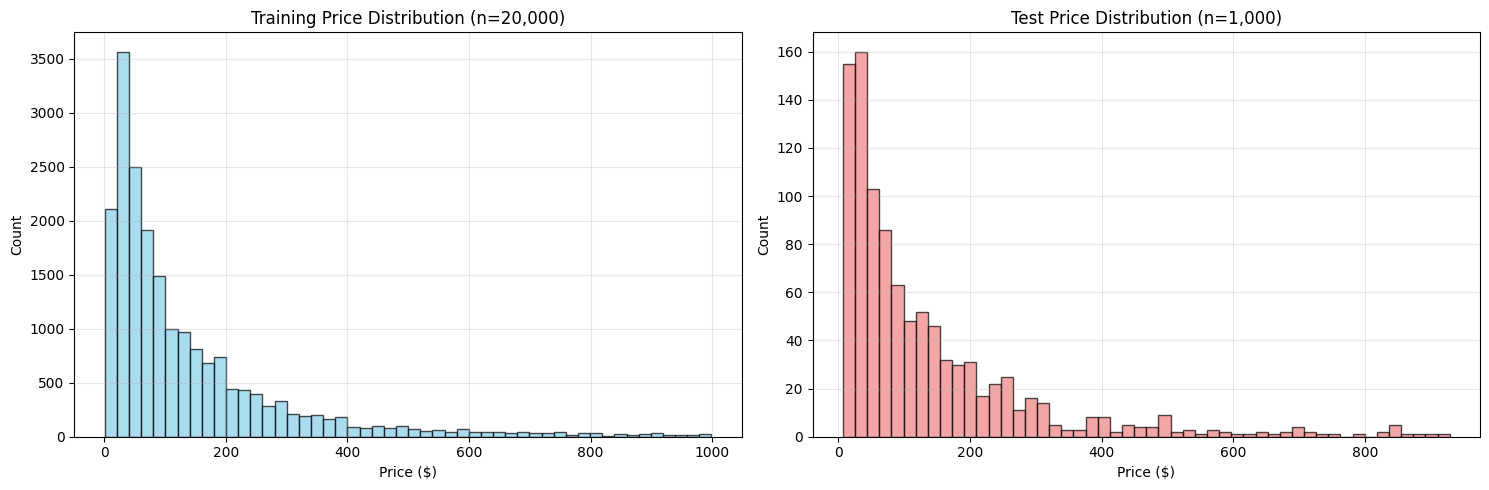

In [90]:
# Visualize price distributions

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_prices, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Training Price Distribution (n={len(train):,})')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

axes[1].hist(test_prices, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Test Price Distribution (n={len(test):,})')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Step 2: Create Balanced Training Sets


In [91]:
# Helper functions

def categorize_price(price):
    """Categorize price into ranges"""
    if price < 50:
        return '$0-50'
    elif price < 100:
        return '$50-100'
    elif price < 300:
        return '$100-300'
    else:
        return '$300+'

def create_balanced_dataset(items, size, validation_split=0.1, seed=42):
    """Create balanced dataset with even distribution across price ranges"""
    random.seed(seed)
    
    # Group by price range
    price_buckets = defaultdict(list)
    for item in items:
        bucket = categorize_price(item.price)
        price_buckets[bucket].append(item)
    
    # Sample equally from each bucket
    items_per_bucket = size // len(price_buckets)
    selected_items = []
    
    for bucket, bucket_items in price_buckets.items():
        sample_size = min(items_per_bucket, len(bucket_items))
        selected_items.extend(random.sample(bucket_items, sample_size))
    
    # Shuffle and split
    random.shuffle(selected_items)
    val_size = int(len(selected_items) * validation_split)
    
    return selected_items[val_size:], selected_items[:val_size]

def show_balance(dataset, name):
    """Display dataset balance"""
    prices = [item.price for item in dataset]
    categories = Counter([categorize_price(p) for p in prices])
    print(f"\n{name}:")
    for cat in ['$0-50', '$50-100', '$100-300', '$300+']:
        count = categories[cat]
        pct = count/len(dataset)*100 if len(dataset) > 0 else 0
        print(f"  {cat}: {count:,} ({pct:.1f}%)")


In [92]:
# Create different sized datasets

print("Creating balanced training sets...\n")

train_500, val_500 = create_balanced_dataset(train, 500, VALIDATION_SPLIT)
print(f"500 examples: {len(train_500)} train + {len(val_500)} val")

train_1000, val_1000 = create_balanced_dataset(train, 1000, VALIDATION_SPLIT)
print(f"1000 examples: {len(train_1000)} train + {len(val_1000)} val")

train_2000, val_2000 = create_balanced_dataset(train, 2000, VALIDATION_SPLIT)
print(f"2000 examples: {len(train_2000)} train + {len(val_2000)} val")

# Select based on configuration
if TRAINING_SIZE == 500:
    selected_train, selected_val = train_500, val_500
elif TRAINING_SIZE == 1000:
    selected_train, selected_val = train_1000, val_1000
else:
    selected_train, selected_val = train_2000, val_2000

print(f"\n👉 Using {len(selected_train)} train + {len(selected_val)} val")
show_balance(selected_train, f"{TRAINING_SIZE}-example Training Set")


Creating balanced training sets...

500 examples: 450 train + 50 val
1000 examples: 900 train + 100 val
2000 examples: 1800 train + 200 val

👉 Using 900 train + 100 val

1000-example Training Set:
  $0-50: 223 (24.8%)
  $50-100: 226 (25.1%)
  $100-300: 224 (24.9%)
  $300+: 227 (25.2%)


## Step 3: Prepare JSONL Files for Fine-Tuning


In [ ]:
# JSONL conversion functions

def messages_for(item, strategy='baseline'):
    """Create message format for training"""
    system_message = PROMPT_STRATEGIES[strategy]['system']
    user_prompt =  f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"
    
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

def make_jsonl(items, strategy='baseline'):
    """Convert items to JSONL format"""
    result = ""
    for item in items:
        messages = messages_for(item, strategy)
        result += '{"messages": ' + json.dumps(messages) + '}\n'
    return result.strip()

def write_jsonl(items, filename, strategy='baseline'):
    """Write JSONL file"""
    with open(filename, "w") as f:
        f.write(make_jsonl(items, strategy))
    print(f"Written {len(items)} items to {filename}")

# Test
print("Example message:")
print(json.dumps(messages_for(selected_train[0], PROMPT_STRATEGY), indent=2)[:200] + "...")


In [ ]:
# Write JSONL files

print(f"Using prompt strategy: '{PROMPT_STRATEGY}'\n")
write_jsonl(selected_train, "fine_tune_train.jsonl", PROMPT_STRATEGY)
write_jsonl(selected_val, "fine_tune_validation.jsonl", PROMPT_STRATEGY)


## Sample: Free / low-cost fine-tune (Hugging Face LoRA)

Runs **locally at no API cost**. Uses a small balanced subset (`SAMPLE_LORA_SIZE`). Requires: `pip install transformers peft trl datasets accelerate` and `HF_TOKEN` for the base model.


In [104]:
# Run a free LoRA fine-tune on a small sample (set SAMPLE_LORA_SIZE to 0 in Config to skip)

LORA_SAMPLE_DIR = "./pricer_lora_sample"
sample_lora_model = None
sample_lora_tokenizer = None

if SAMPLE_LORA_SIZE > 0:
    import subprocess
    subprocess.check_call(["pip", "install", "--upgrade", "accelerate>=0.26.0", "-q"])
    from datasets import Dataset
    from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
    from peft import LoraConfig, get_peft_model
    from trl import SFTTrainer
    import torch
    MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
    sample_train, sample_val = create_balanced_dataset(train, SAMPLE_LORA_SIZE, VALIDATION_SPLIT)
    def item_to_messages(it):
        return [{"role": m["role"], "content": m["content"]} for m in messages_for(it, PROMPT_STRATEGY)]
    train_data = [{"messages": item_to_messages(it)} for it in sample_train]
    val_data = [{"messages": item_to_messages(it)} for it in sample_val]
    train_ds = Dataset.from_list(train_data)
    val_ds = Dataset.from_list(val_data)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")
    def format_instruction(ex):
        return {"text": tokenizer.apply_chat_template(ex["messages"], tokenize=False, add_generation_prompt=False)}
    train_ds = train_ds.map(format_instruction, remove_columns=train_ds.column_names)
    val_ds = val_ds.map(format_instruction, remove_columns=val_ds.column_names)
    peft_config = LoraConfig(r=8, lora_alpha=16, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    model = get_peft_model(model, peft_config)
    trainer = SFTTrainer(model=model, tokenizer=tokenizer, train_dataset=train_ds, eval_dataset=val_ds, dataset_text_field="text", max_seq_length=512,
        args=TrainingArguments(output_dir=LORA_SAMPLE_DIR, num_train_epochs=1, per_device_train_batch_size=2, per_device_eval_batch_size=2, gradient_accumulation_steps=2, eval_strategy="epoch", save_strategy="epoch", logging_steps=10, fp16=torch.cuda.is_available()))
    trainer.train()
    trainer.save_model(LORA_SAMPLE_DIR)
    tokenizer.save_pretrained(LORA_SAMPLE_DIR)
    sample_lora_model = model
    sample_lora_tokenizer = tokenizer
    print(f"Sample LoRA model saved to {LORA_SAMPLE_DIR} ({len(sample_train)} train, {len(sample_val)} val)")
else:
    print("SAMPLE_LORA_SIZE is 0; skipping free sample fine-tune.")


Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=0.26.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=0.26.0'`

In [ ]:
# Load sample LoRA model and define predictor (run after the sample fine-tune cell, or load from disk)

try:
    _ = sample_lora_model
except NameError:
    sample_lora_model = None
    sample_lora_tokenizer = None
LORA_SAMPLE_DIR = "./pricer_lora_sample"
import os
if (sample_lora_model is None or sample_lora_tokenizer is None) and os.path.isdir(LORA_SAMPLE_DIR):
    from peft import PeftModel
    from transformers import AutoModelForCausalLM, AutoTokenizer
    import torch
    sample_lora_tokenizer = AutoTokenizer.from_pretrained(LORA_SAMPLE_DIR, trust_remote_code=True)
    base = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")
    sample_lora_model = PeftModel.from_pretrained(base, LORA_SAMPLE_DIR)
    print(f"Loaded sample LoRA from {LORA_SAMPLE_DIR}")

def get_price(s):
    s = str(s).replace("$", "").replace(",", "")
    m = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(m.group()) if m else 0.0

def gpt_sample_lora(item):
    if sample_lora_model is None or sample_lora_tokenizer is None:
        raise RuntimeError("Run the sample LoRA training cell first (SAMPLE_LORA_SIZE > 0) or ensure pricer_lora_sample exists.")
    msgs = [{"role": "system", "content": PROMPT_STRATEGIES[PROMPT_STRATEGY]["system"]}, {"role": "user", "content": f"Estimate the price of this product. Respond with the price, no explanation\n\n{item.summary}"}, {"role": "assistant", "content": "Price is $"}]
    text = sample_lora_tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = sample_lora_tokenizer(text, return_tensors="pt").to(sample_lora_model.device)
    out = sample_lora_model.generate(**inputs, max_new_tokens=20, do_sample=False, pad_token_id=sample_lora_tokenizer.eos_token_id)
    reply = sample_lora_tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return get_price(reply)

if SAMPLE_LORA_SIZE > 0 and sample_lora_model is not None:
    t0 = test[0]
    p = gpt_sample_lora(t0)
    print(f"Sample: {t0.title[:50]}...")
    print(f"Predicted: ${p:.2f}, Actual: ${t0.price:.2f}")


In [ ]:
# Evaluate the free sample LoRA model (run after loading cell above)

if SAMPLE_LORA_SIZE > 0 and sample_lora_model is not None:
    Tester.test(gpt_sample_lora, test)
else:
    print("Skip: no sample LoRA model. Set SAMPLE_LORA_SIZE > 0 and run the sample fine-tune cell.")


## Step 4: Upload Files to OpenAI


In [99]:
# Upload training file

with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai_ft.files.create(file=f, purpose="fine-tune")

print(f"Training file uploaded: {train_file.id}")
train_file


Training file uploaded: file-1E3xNGKyqMr3N3TtrjSr6P


FileObject(id='file-1E3xNGKyqMr3N3TtrjSr6P', bytes=731170, created_at=1773036181, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [101]:
# Upload validation file

with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai_ft.files.create(file=f, purpose="fine-tune")

print(f"Validation file uploaded: {validation_file.id}")
validation_file


Validation file uploaded: file-H6bdayaNscyxrdZgSTiZNY


FileObject(id='file-H6bdayaNscyxrdZgSTiZNY', bytes=80942, created_at=1773036352, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

## Step 5: Create Fine-Tuning Job

**Optional**: Set up Weights & Biases at https://wandb.ai for training monitoring


In [ ]:
# Create fine-tuning job

wandb_integration = {"type": "wandb", "wandb": {"project": "product-pricer-improved"}}

print(f"Starting fine-tuning:")
print(f"  Model: gpt-4o-mini-2024-07-18")
print(f"  Training: {len(selected_train)} examples")
print(f"  Validation: {len(selected_val)} examples")
print(f"  Epochs: {N_EPOCHS}\n")

fine_tune_job = openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": N_EPOCHS},
    integrations=[wandb_integration],
    suffix="pricer-improved"
)

job_id = fine_tune_job.id
print(f"Job created: {job_id}")
print(f"   Status: {fine_tune_job.status}")

# Save configuration
config = {
    "job_id": job_id,
    "training_size": TRAINING_SIZE,
    "prompt_strategy": PROMPT_STRATEGY,
    "n_epochs": N_EPOCHS
}

with open("training_config.json", "w") as f:
    json.dump(config, f, indent=2)
with open("job_id.txt", "w") as f:
    f.write(job_id)

print("\n Config saved to training_config.json")
fine_tune_job


In [ ]:
# Check job status (run this cell to monitor progress)

status = openai.fine_tuning.jobs.retrieve(job_id)
print(f"Job Status: {status.status}\n")

# Show recent events
events = openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=5)
print("Recent events:")
for event in events.data[::-1]:
    print(f"  {event.message}")

status


In [ ]:
# Get fine-tuned model name and final status

job_status = openai.fine_tuning.jobs.retrieve(job_id)
fine_tuned_model_name = job_status.fine_tuned_model

if fine_tuned_model_name:
    print(f" Model ready: {fine_tuned_model_name}")
    if job_status.trained_tokens:
        print(f"   Trained tokens: {job_status.trained_tokens:,}")
else:
    print(f"Still training... Status: {job_status.status}")
    print(" Run this cell again in a few minutes")


## Step 6: Evaluate the Fine-Tuned Model


In [ ]:
# Prediction function

def get_price(s):
    """Extract price from response"""
    s = s.replace('$', '').replace(',', '')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

def gpt_fine_tuned_improved(item):
    """Get price prediction from our model"""
    system_message = PROMPT_STRATEGIES[PROMPT_STRATEGY]['system']
    user_prompt = item.test_prompt().replace(" to the nearest dollar", "").replace("\n\nPrice is $", "")
    
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]
    
    response = openai.chat.completions.create(
        model=fine_tuned_model_name,
        messages=messages,
        seed=42,
        max_tokens=10,
        temperature=0
    )
    
    return get_price(response.choices[0].message.content)

# Test on one item
sample = test[0]
pred = gpt_fine_tuned_improved(sample)
print(f"Product: {sample.title[:60]}...")
print(f"Predicted: ${pred:.2f}")
print(f"Actual: ${sample.price:.2f}")
print(f"Error: ${abs(pred - sample.price):.2f}")


In [ ]:
# Run full evaluation on 250 test items

print("Running comprehensive evaluation...\n")
print("This will take a few minutes.\n")
print("="*80 + "\n")

evalu.test(gpt_fine_tuned_improved, test)
